# Import PyTorch

In [47]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.13.0+cu126
True
NVIDIA GeForce RTX 4070 SUPER


# Setup GPU as device

In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Load dataset

In [49]:
from torchvision import datasets
from torchvision.transforms import ToTensor

train_data = datasets.MNIST(
    root="data",
    train=True,
    transform=ToTensor(),
    download=True
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    transform=ToTensor()
)

In [50]:
print(f"Train dataset size: {len(train_data)}\nTest dataset size: {len(test_data)}")
print(f"Data shape: {train_data[0][0].shape} and first label is {train_data[0][1]}")

Train dataset size: 60000
Test dataset size: 10000
Data shape: torch.Size([1, 28, 28]) and first label is 5


# Vizualize a few examples

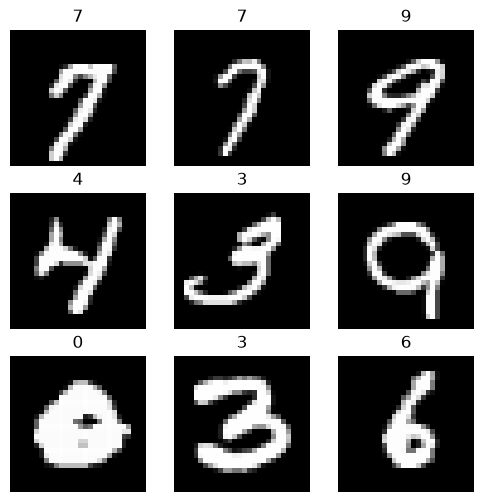

In [51]:
import matplotlib.pyplot as plt

figure = plt.figure(figsize=(6, 6))

cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

# Create Dataloader

In [52]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    train_data, 
    batch_size=64, 
    shuffle=True
)

test_dataloader = DataLoader(
    test_data, 
    batch_size=64, 
    shuffle=False
)

In [53]:
images, labels = next(iter(train_dataloader))
print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


## Note
torch.Size([64, 1, 28, 28])
64 => elements in batch
1 => canal, MNIST use gray-scale so the canal is 1
28, 28 => height and width

# Create a model and train the model

In [80]:
import torch.nn as nn
import torch.optim as optim

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)


model = NeuralNetwork()

loss_fn = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01
)

epochs = 5

for epoch in range(epochs):
    total_loss = 0
    correct_predictions = 0

    for images, labels in train_dataloader:

        optimizer.zero_grad()

        output = model(images)

        # Loss
        loss = loss_fn(output, labels)
        total_loss += loss.item()

        # Correct predictions (argmax => the higest values from 0-9)
        predicted = output.argmax(1)
        correct_predictions += (predicted == labels).sum().item()

        loss.backward()

        optimizer.step()
    
    average_loss = total_loss / len(train_dataloader)
    accuracy = correct_predictions / len(train_data)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Loss: {average_loss:.4f} | "
        f"Accuracy: {accuracy * 100:.2f}%")

Epoch 1/5 | Loss: 1.2298 | Accuracy: 74.90%
Epoch 2/5 | Loss: 0.4956 | Accuracy: 87.64%
Epoch 3/5 | Loss: 0.3933 | Accuracy: 89.32%
Epoch 4/5 | Loss: 0.3520 | Accuracy: 90.14%
Epoch 5/5 | Loss: 0.3269 | Accuracy: 90.75%
